# ****Mevsimsel Verilerin ve İnsan Etkilerinin Analizi***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/forestfires.csv')

print(f"Veri Seti Boyutu: {df.shape[0]} Satır, {df.shape[1]} Sütun\n")
print(f"Toplam Eksik Veri (NaN) Sayısı: {df.isnull().sum().sum()}\n")

display(df.head(10))
display(df.describe().T)

Veri Seti Boyutu: 517 Satır, 13 Sütun

Toplam Eksik Veri (NaN) Sayısı: 0



,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.0,3.0,4.00,7.00,9.00
Y,517.0,4.299807,1.229900,2.0,4.0,4.00,5.00,9.00
FFMC,517.0,90.644681,5.520111,18.7,90.2,91.60,92.90,96.20
DMC,517.0,110.872340,64.046482,1.1,68.6,108.30,142.40,291.30
DC,517.0,547.940039,248.066192,7.9,437.7,664.20,713.90,860.60
ISI,517.0,9.021663,4.559477,0.0,6.5,8.40,10.80,56.10
temp,517.0,18.889168,5.806625,2.2,15.5,19.30,22.80,33.30
RH,517.0,44.288201,16.317469,15.0,33.0,42.00,53.00,100.00
wind,517.0,4.017602,1.791653,0.4,2.7,4.00,4.90,9.40
rain,517.0,0.021663,0.295959,0.0,0.0,0.00,0.00,6.40


## Aylık ve Günlük Yangın Dinamikleri: 

### Amaç
Yangınların **Aylara (`month`)** ve **Haftanın Günlerine (`day / is_weekend`)** göre frekansını (sayısını), toplam yanan alanını ve yangın başına düşen ortalama tahribatını incelemek.

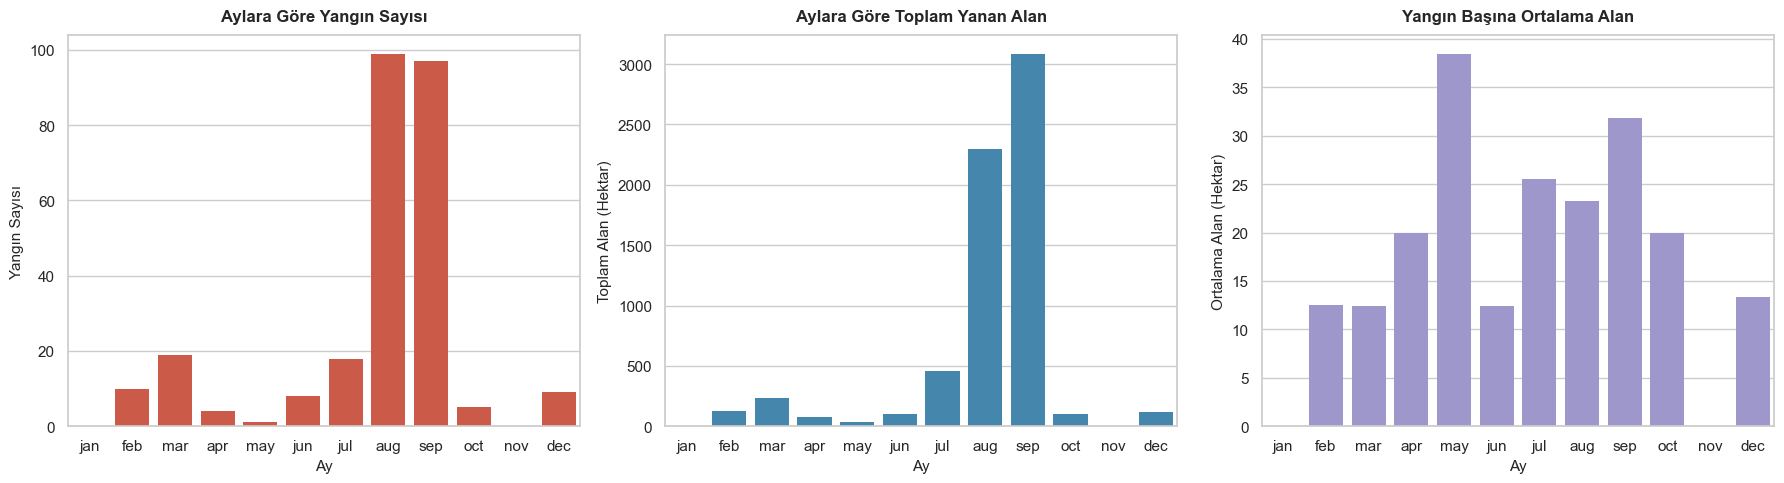

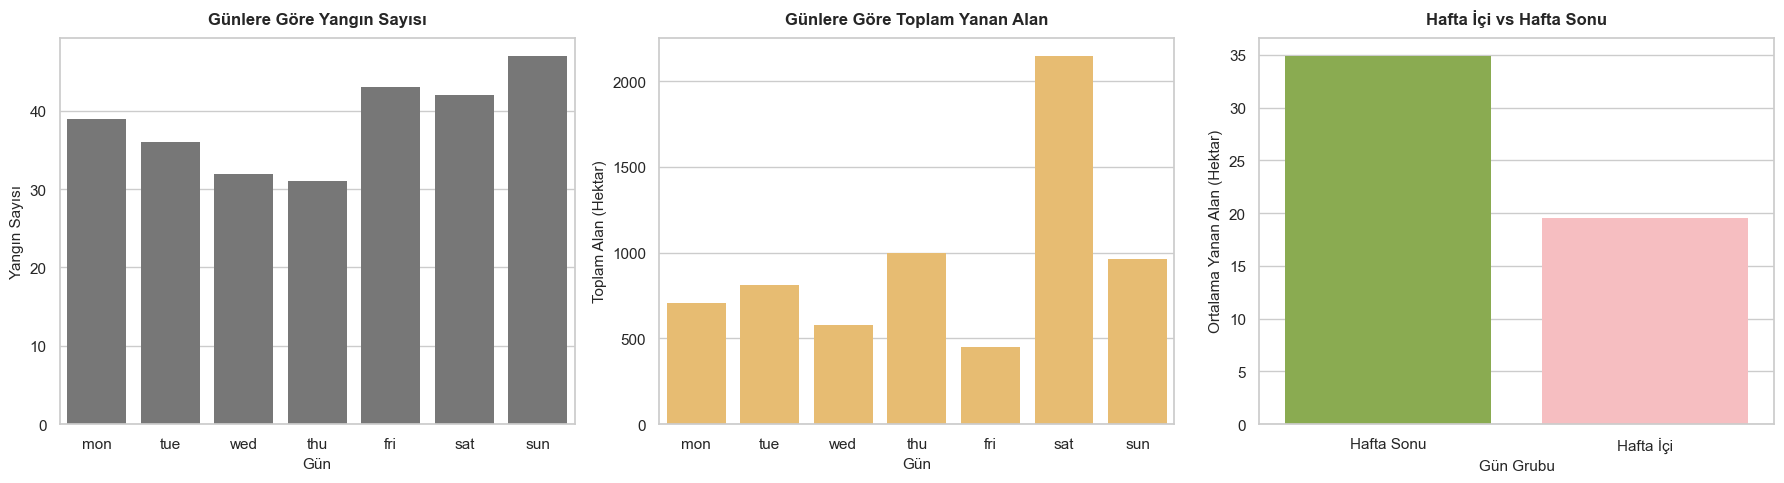

--- HAFTA İÇİ vs HAFTA SONU YANGIN ÖZETİ ---


,is_weekend,count,sum,mean
0,Hafta Sonu,89,3104.79,34.89
1,Hafta İçi,181,3537.26,19.54


In [8]:
ay_sirasi = [
    'jan',
    'feb',
    'mar',
    'apr',
    'may',
    'jun',
    'jul',
    'aug',
    'sep',
    'oct',
    'nov',
    'dec',
]
gun_sirasi = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df['month'] = pd.Categorical(df['month'], categories=ay_sirasi, ordered=True)
df['day'] = pd.Categorical(df['day'], categories=gun_sirasi, ordered=True)

df['is_weekend'] = df['day'].isin(['sat', 'sun']).map({True: 'Hafta Sonu', False: 'Hafta İçi'})

yanginlar = df[df['area'] > 0].copy()

aylik_ozet = (
    yanginlar.groupby('month', observed=True)['area']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=aylik_ozet,
    x='month',
    y='count',
    color = '#E24A33',
    ax=axes[0],
    edgecolor='none',
)
axes[0].set_title(
    'Aylara Göre Yangın Sayısı',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('Ay', fontsize=11)
axes[0].set_ylabel('Yangın Sayısı', fontsize=11)

sns.barplot(
    data=aylik_ozet,
    x='month',
    y='sum',
    color = '#348ABD',
    ax=axes[1],
    edgecolor='none',
)
axes[1].set_title(
    'Aylara Göre Toplam Yanan Alan',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Ay', fontsize=11)
axes[1].set_ylabel('Toplam Alan (Hektar)', fontsize=11)

sns.barplot(
    data=aylik_ozet,
    x='month',
    y='mean',
    color='#988ED5',
    ax=axes[2],
    edgecolor='none',
)
axes[2].set_title(
    'Yangın Başına Ortalama Alan',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[2].set_xlabel('Ay', fontsize=11)
axes[2].set_ylabel('Ortalama Alan (Hektar)', fontsize=11)

plt.tight_layout()
plt.show()

gunluk_ozet = (
    yanginlar.groupby('day', observed=True)['area']
    .agg(['count', 'sum'])
    .reset_index()
)
haftasonu_ozet = (
    yanginlar.groupby('is_weekend', observed=True)['area']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=gunluk_ozet,
    x='day',
    y='count',
    color='#777777',
    ax=axes[0],
    edgecolor='none',
)
axes[0].set_title(
    'Günlere Göre Yangın Sayısı',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('Gün', fontsize=11)
axes[0].set_ylabel('Yangın Sayısı', fontsize=11)

sns.barplot(
    data=gunluk_ozet,
    x='day',
    y='sum',
    color='#FBC15E',
    ax=axes[1],
    edgecolor='none',
)
axes[1].set_title(
    'Günlere Göre Toplam Yanan Alan',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Gün', fontsize=11)
axes[1].set_ylabel('Toplam Alan (Hektar)', fontsize=11)

sns.barplot(
    data=haftasonu_ozet,
    x='is_weekend',
    y='mean',
    palette=['#8EBA42', '#FFB5B8'],
    ax=axes[2],
    edgecolor='none',
)
axes[2].set_title(
    'Hafta İçi vs Hafta Sonu',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[2].set_xlabel('Gün Grubu', fontsize=11)
axes[2].set_ylabel('Ortalama Yanan Alan (Hektar)', fontsize=11)

plt.tight_layout()
plt.show()

print('--- HAFTA İÇİ vs HAFTA SONU YANGIN ÖZETİ ---')
display(haftasonu_ozet.round(2))

* **Ağustos-Eylül Ayının Önemi:**
  * Yangın vakalarının %73'ü ve toplam tahribatın neredeyse tamamı Ağustos ve Eylül aylarında gerçekleşmektedir. Ancak sağ üst paneldeki `Mayıs (may)` ayına dikkat ederseniz: Vaka sayısı az olmasına rağmen **yangın başına ortalama alan en yüksek (`~38 ha`)** Mayıs ayındadır! Bu durum, mevsim geçişlerinde çıkan ani yangınların hazırlıksız yakalanıldığında ne kadar tehlikeli yayılabildiğini gösterir.
* Ancak alt panel ve özet tablosu muazzam bir gerçeği kanıtlamıştır: **Hafta sonu (`is_weekend = True`) yangın başına ortalama alan `34.89 hektar` iken, hafta içi (`False`) `19.54 hektardır`** Cumartesi günü tek başına `2200 hektarlık` yıkım üretmiştir.

## Gün ve Ay Çapraz Etkileşimi (`day x month` 2D Isı Haritası)

### Amaç
Ayların ve günlerin tekil etkilerini birleştirerek, yılın hangi spesifik takvim kesişimlerinde (`Ay x Gün`) **Yangın Çıkma Sıklığının (Frekans)** zirve yaptığını ve hangi kesişimlerde **Toplam Yıkımın (Hektar)** çift panelli 2D çapraz ısı haritası ile ortaya çıkarmak.

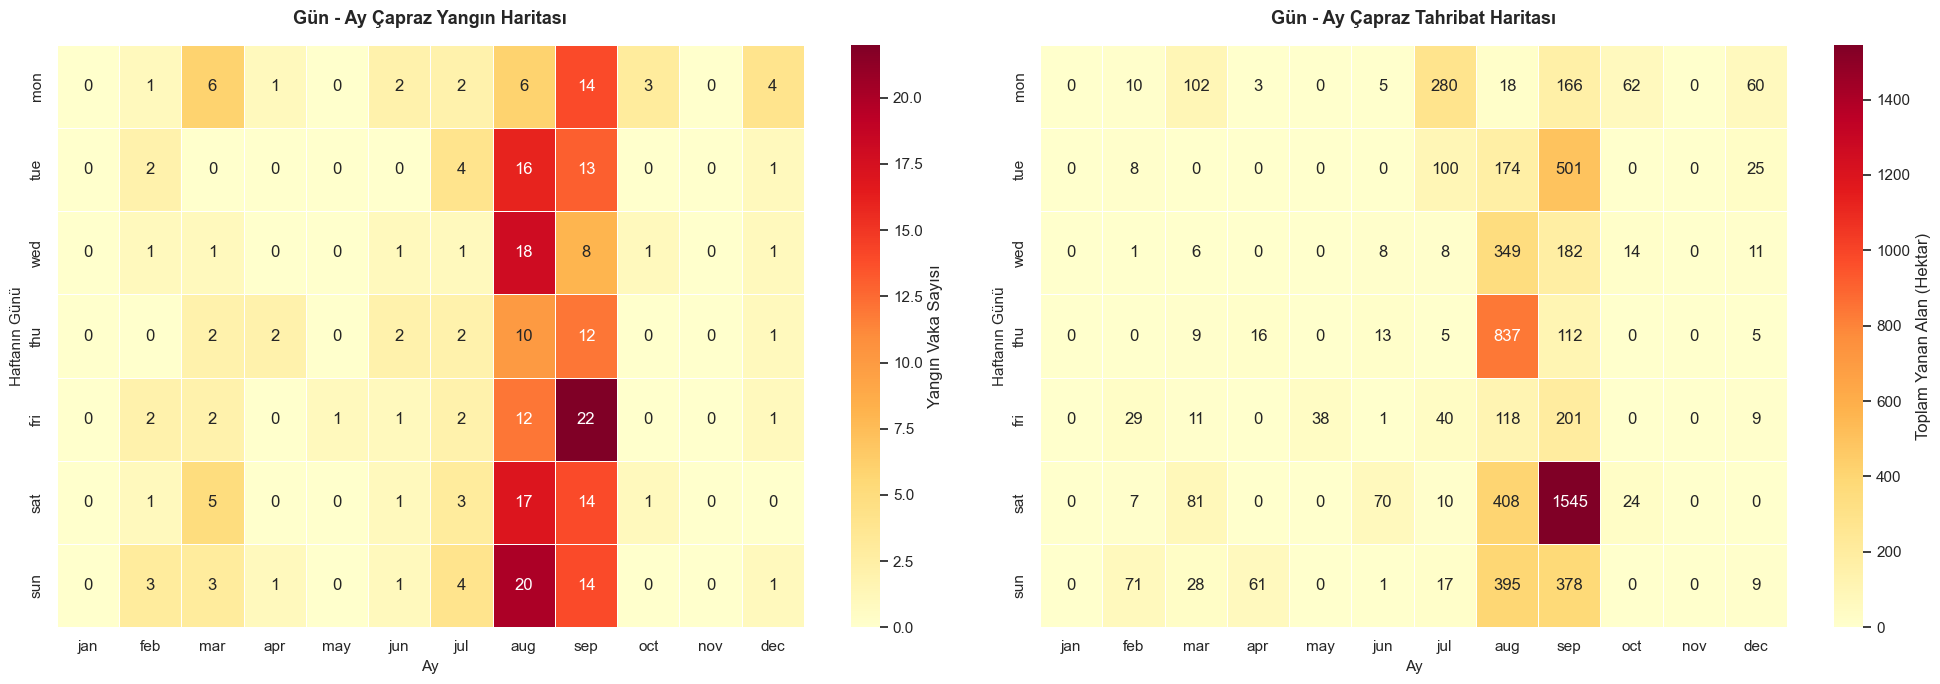

Zaman: [SEP ayının SAT günü] -> 14 yangında toplam 1545.11 ha yanmış, (Ortalama: 110.37 ha/yangın)
Zaman: [AUG ayının THU günü] -> 10 yangında toplam 837.17 ha yanmış, (Ortalama: 83.72 ha/yangın)
Zaman: [SEP ayının TUE günü] -> 13 yangında toplam 500.69 ha yanmış, (Ortalama: 38.51 ha/yangın)


In [9]:
ay_sirasi = [
    'jan',
    'feb',
    'mar',
    'apr',
    'may',
    'jun',
    'jul',
    'aug',
    'sep',
    'oct',
    'nov',
    'dec',
]
gun_sirasi = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df['month'] = pd.Categorical(df['month'], categories=ay_sirasi, ordered=True)
df['day'] = pd.Categorical(df['day'], categories=gun_sirasi, ordered=True)

yanginlar = df[df['area'] > 0].copy()

frekans_matrisi = (
    yanginlar.pivot_table(index='day', columns='month', values='area', aggfunc='count')
    .reindex(index=gun_sirasi, columns=ay_sirasi)
    .fillna(0)
)

alan_matrisi = (
    yanginlar.pivot_table(index='day', columns='month', values='area', aggfunc='sum')
    .reindex(index=gun_sirasi, columns=ay_sirasi)
    .fillna(0)
)

sns.set_theme(style='white')
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(
    frekans_matrisi,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Yangın Vaka Sayısı'},
    ax=axes[0],
)
axes[0].set_title(
    'Gün - Ay Çapraz Yangın Haritası',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Ay', fontsize=11)
axes[0].set_ylabel('Haftanın Günü', fontsize=11)
sns.heatmap(
    alan_matrisi,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Toplam Yanan Alan (Hektar)'},
    ax=axes[1],
)
axes[1].set_title(
    'Gün - Ay Çapraz Tahribat Haritası',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Ay', fontsize=11)
axes[1].set_ylabel('Haftanın Günü', fontsize=11)

plt.tight_layout()
plt.show()
en_tehlikeli_zamanlar = (
    yanginlar.groupby(['month', 'day'], observed=True)['area']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
    .sort_values(by='sum', ascending=False)
    .head(3)
)

for idx, row in en_tehlikeli_zamanlar.iterrows():
    print(
        f"Zaman: [{row['month'].upper()} ayının {row['day'].upper()} günü] -> {row['count']} yangında toplam {row['sum']:.2f} ha yanmış, (Ortalama: {row['mean']:.2f} ha/yangın)"
    )

Bu ısı haritasına baktığımızda ilk gözümüze çarpan şey, **"yangın çıkma sıklığı" ile "yıkım büyüklüğünün" tamamen farklı günlerde zirve yapması oluyor.** 

Sol haritaya bakarsak parkta en çok yangın ihbarı alınan günün **Eylül Cuma (`22 yangın`)** olduğunu görüyoruz. Normalde en büyük tahribatın da bu günde olmasını bekleriz ancak Eylül Cuma günü toplamda sadece `201 hektar` alan yanmışken, hemen ertesi gün olan **Eylül Cumartesi (`SEP - SAT`) sadece 14 yangında `1545 hektar` yanmış**

## Mevsimlere Göre Yangın Tahribatı Haritası

### Amaç
Ayların ve mekansal blokların tek başlarına incelenmesi yerine; parktaki yangın tahribatının **Mevsimlere (`İlkbahar&Kış vs Yaz vs Sonbahar`)** göre 9x9 grid haritası (`X, Y`) üzerinde nasıl hareket ettiğini izlemek ve tehlikenin mevsimsel olarak nereye "göç ettiğini" keşfetmek.

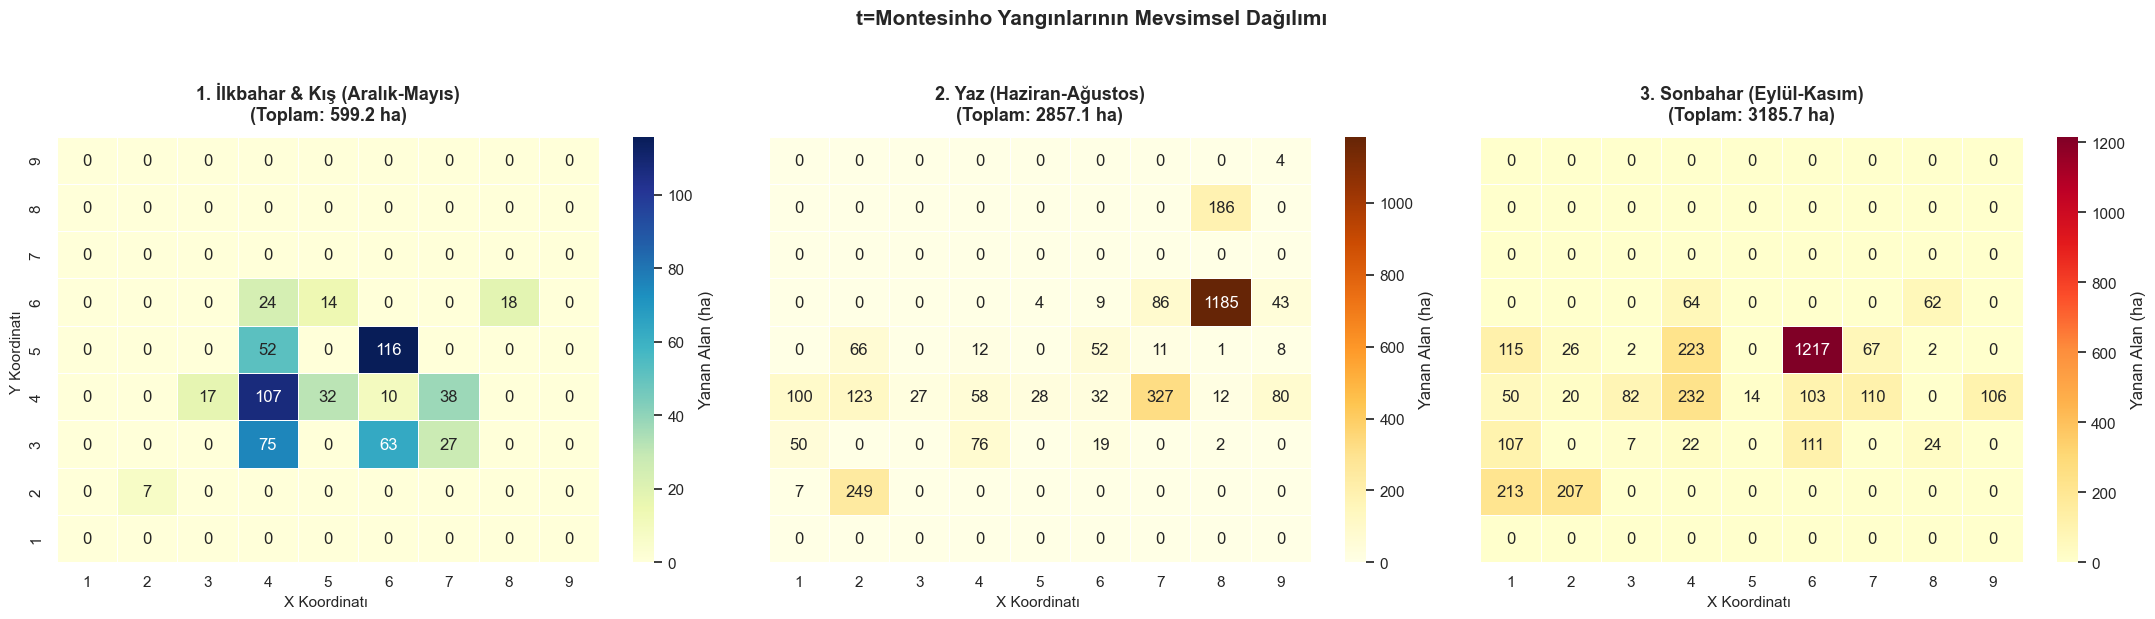

--- MEVSİMLERE GÖRE YANGININ  ---
[1. İlkbahar & Kış (Aralık-Mayıs)] -> En Tehlikeli Blok: [X=6, Y=5] -> Toplam 115.78 hektar yanmış
[2. Yaz (Haziran-Ağustos)] -> En Tehlikeli Blok: [X=8, Y=6] -> Toplam 1184.87 hektar yanmış
[3. Sonbahar (Eylül-Kasım)] -> En Tehlikeli Blok: [X=6, Y=5] -> Toplam 1216.51 hektar yanmış


In [10]:
mevsim_sozlugu = {
    'dec': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'jan': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'feb': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'mar': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'apr': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'may': '1. İlkbahar & Kış (Aralık-Mayıs)',
    'jun': '2. Yaz (Haziran-Ağustos)',
    'jul': '2. Yaz (Haziran-Ağustos)',
    'aug': '2. Yaz (Haziran-Ağustos)',
    'sep': '3. Sonbahar (Eylül-Kasım)',
    'oct': '3. Sonbahar (Eylül-Kasım)',
    'nov': '3. Sonbahar (Eylül-Kasım)',
}
df['deneysel_mevsim'] = df['month'].map(mevsim_sozlugu)
yanginlar = df[df['area'] > 0].copy()

sns.set_theme(style='white')
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True, sharey=True)
mevsimler = sorted(df['deneysel_mevsim'].unique())
renk_paletleri = [
    'YlGnBu',
    'YlOrBr',
    'YlOrRd',
]  

for i, mevsim in enumerate(mevsimler):
    mevsim_verisi = yanginlar[yanginlar['deneysel_mevsim'] == mevsim]
    izgara_matrisi = (
        mevsim_verisi.pivot_table(index='Y', columns='X', values='area', aggfunc='sum')
        .reindex(index=range(1, 10), columns=range(1, 10))
        .fillna(0)
    )
    
    sns.heatmap(
        izgara_matrisi.iloc[::-1],
        annot=True,
        fmt='.0f',
        cmap=renk_paletleri[i],
        linewidths=0.5,
        cbar_kws={'label': 'Yanan Alan (ha)'},
        ax=axes[i],
    )
    axes[i].set_title(
        f'{mevsim}\n(Toplam: {mevsim_verisi["area"].sum():.1f} ha)',
        fontsize=13,
        fontweight='bold',
        pad=12,
    )
    axes[i].set_xlabel('X Koordinatı ', fontsize=11)
    if i == 0:
        axes[i].set_ylabel('Y Koordinatı ', fontsize=11)
    else:
        axes[i].set_ylabel('')
plt.suptitle( "t=Montesinho Yangınlarının Mevsimsel Dağılımı",
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.show()
print('--- MEVSİMLERE GÖRE YANGININ  ---')
for mevsim in mevsimler:
    mevsim_verisi = yanginlar[yanginlar['deneysel_mevsim'] == mevsim]
    zirve_blok = (
        mevsim_verisi.groupby(['X', 'Y'], observed=True)['area']
        .sum()
        .reset_index()
        .sort_values(by='area', ascending=False)
        .iloc[0]
    )
    print(
        f"[{mevsim}] -> En Tehlikeli Blok: [X={int(zirve_blok['X'])}, Y={int(zirve_blok['Y'])}] -> Toplam {zirve_blok['area']:.2f} hektar yanmış"
    )

Yaz ayları (`Haziran - Ağustos`) geldiğinde parkın toplam kaybı `2857 hektara` çıkıyor.Sonbahar (`Eylül - Kasım`) geldiğinde de toplam tahribat daha da büyüyerek `3185 hektara` ulaşıyor.

Bu hareketliliğin sırrı yine **Liao et al. (2025)** ve **Dong et al. (2022)** makalelerinde belirtiliyor: **İnsani aktiviteleri**
* **Yazın (`X=8, Y=6`):** Yaz aylarında parkın kamp alanlarına ve su kenarlarına gelen turist ile piknikçi yoğunluğu (`Human Nearness Index`) güney/doğu hatlarında zirve yapıyor.
* **Sonbaharın (`X=6, Y=5`):** Sonbaharda turistler çekildiğinde ise sahnede köylüler ve çobanlar kalıyor. Parkın merkez vadisinde (`X=6, Y=5`) kış öncesi tarımsal temizlik ateşleri, kestane/mantar toplayıcıla

## Günlük İnsan Faktörünün Keman ve Bar Grafikleri İle Analizi

### Amaç
Haftanın 7 günü boyunca sıcaklık (`temp`) ve bağıl nem (`RH`) dağılımlarını keman grafikleri (`violin plot`) ile inceleyerek hava durumunun haftalık ritmini kontrol etmek; ardından bu ritmi günlük toplam yanan alanla (`area`) karşılaştırarak yangınların arkasındaki asıl tetiğin meteoroloji mi yoksa hafta sonu insan hareketliliği mi olduğunu kesin olarak ispatlamak.

DENEYSEL MAKALE ANALİZİ 2: 7 GÜNLÜK TAM YELPAZEDE İNSAN FAKTÖRÜ İSPATI (ADIM 6.2)


,day_ordered,toplam_gun,ort_sicaklik,medyan_sicaklik,ort_nem,medyan_nem,toplam_yanan_alan,ort_yanan_alan
0,Pazartesi,74,16.95,17.55,44.66,42.0,706.53,9.55
1,Salı,64,19.44,19.40,43.67,41.0,807.79,12.62
2,Çarşamba,54,20.43,20.45,40.11,36.0,578.60,10.71
3,Perşembe,61,19.70,20.40,38.80,38.0,997.10,16.35
4,Cuma,85,17.95,18.70,46.66,43.0,447.24,5.26
5,Cumartesi,84,19.35,19.10,43.40,41.5,2144.86,25.53
6,Pazar,95,19.07,19.80,48.97,44.0,959.93,10.10


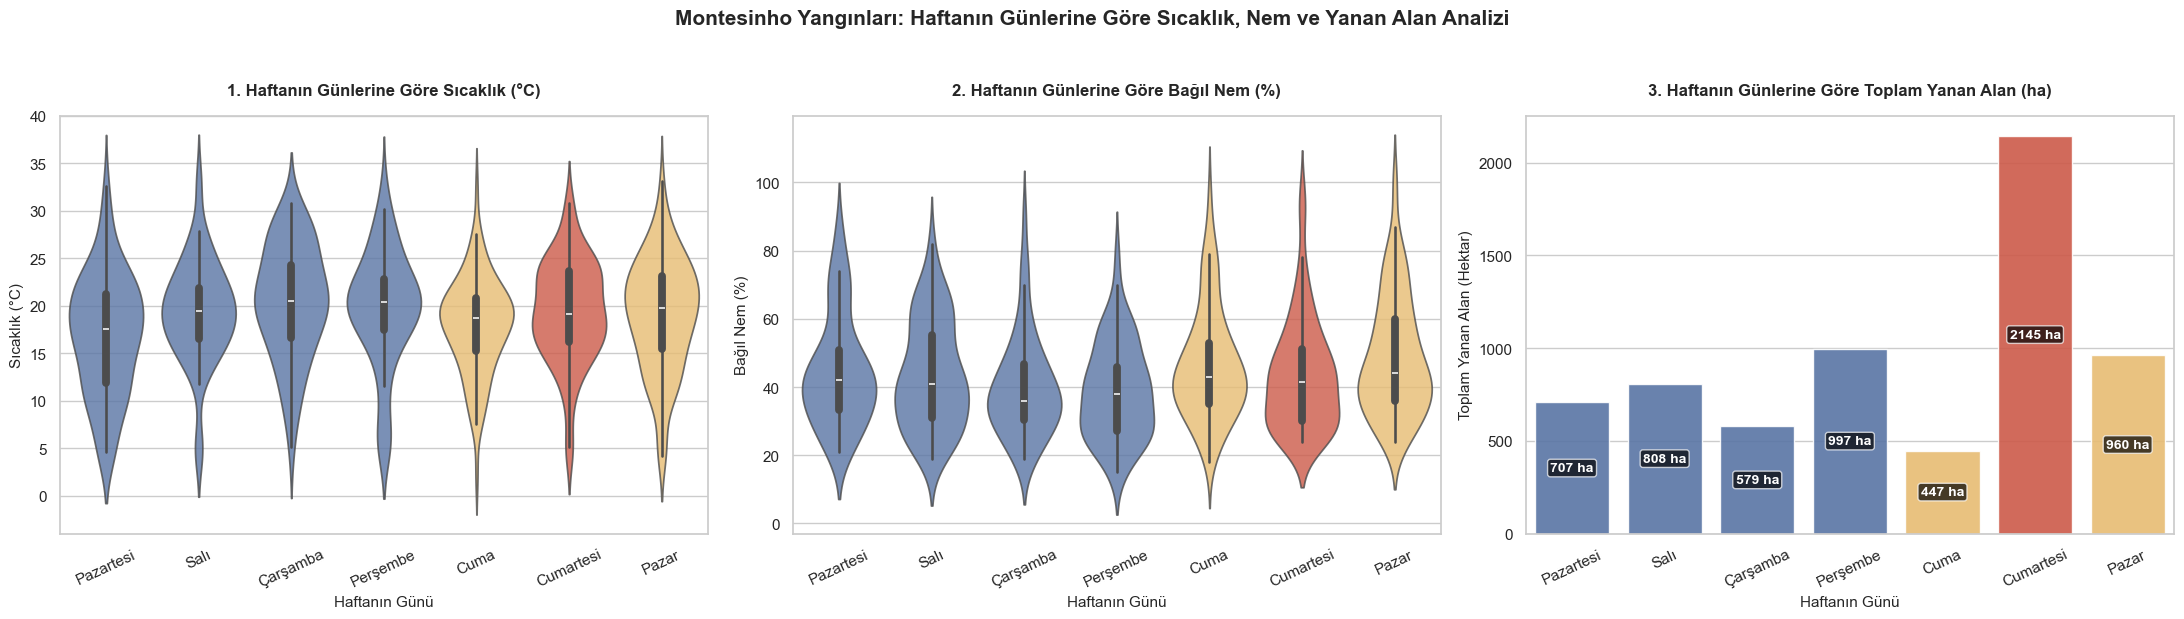

 Hafta İçi Ort. Sıcaklık   : 18.99°C | Ortalama Nem: %42.03
 Hafta Sonu + Cuma Ort. Sıcaklık: 18.80°C | Ortalama Nem: %46.45
  Hafta İçi 4 Günün TOPLAM Yanan Alanı    : 3090.02 hektar (Günlük ort: 772.50 ha)
 Hafta Sonu 3 Günün TOPLAM Yanan Alanı   : 3552.03 hektar (Günlük ort: 1184.01 ha)!


In [11]:
gun_sirasi = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
gun_isimleri_tr = [
    'Pazartesi',
    'Salı',
    'Çarşamba',
    'Perşembe',
    'Cuma',
    'Cumartesi',
    'Pazar',
]

df['day_ordered'] = pd.Categorical(df['day'], categories=gun_sirasi, ordered=True)

gunluk_analiz = (
    df.groupby('day_ordered', observed=True)
    .agg(
        toplam_gun=('day', 'count'),
        ort_sicaklik=('temp', 'mean'),
        medyan_sicaklik=('temp', 'median'),
        ort_nem=('RH', 'mean'),
        medyan_nem=('RH', 'median'),
        toplam_yanan_alan=('area', 'sum'),
        ort_yanan_alan=('area', 'mean'),
    )
    .reset_index()
)

gunluk_analiz['day_ordered'] = gun_isimleri_tr

print('=' * 85)
print(
    'DENEYSEL MAKALE ANALİZİ 2: 7 GÜNLÜK TAM YELPAZEDE İNSAN FAKTÖRÜ İSPATI (ADIM 6.2)'
)
print('=' * 85)
display(gunluk_analiz.round(2))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

palet_7gun = [
    '#4C72B0',
    '#4C72B0',
    '#4C72B0',
    '#4C72B0',
    '#FBC15E',
    '#E24A33',
    '#FBC15E',
]

sns.violinplot(
    data=df,
    x='day_ordered',
    y='temp',
    palette=palet_7gun,
    ax=axes[0],
    inner='boxplot',
    alpha=0.8,
)
axes[0].set_title(
    '1. Haftanın Günlerine Göre Sıcaklık (°C)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Haftanın Günü', fontsize=11)
axes[0].set_ylabel('Sıcaklık (°C)', fontsize=11)
axes[0].set_xticklabels(gun_isimleri_tr, rotation=25)

sns.violinplot(
    data=df,
    x='day_ordered',
    y='RH',
    palette=palet_7gun,
    ax=axes[1],
    inner='boxplot',
    alpha=0.8,
)
axes[1].set_title(
    '2. Haftanın Günlerine Göre Bağıl Nem (%)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Haftanın Günü', fontsize=11)
axes[1].set_ylabel('Bağıl Nem (%)', fontsize=11)
axes[1].set_xticklabels(gun_isimleri_tr, rotation=25)

sns.barplot(
    data=gunluk_analiz,
    x='day_ordered',
    y='toplam_yanan_alan',
    palette=palet_7gun,
    ax=axes[2],
    alpha=0.9,
)
axes[2].set_title(
    '3. Haftanın Günlerine Göre Toplam Yanan Alan (ha)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[2].set_xlabel('Haftanın Günü', fontsize=11)
axes[2].set_ylabel('Toplam Yanan Alan (Hektar)', fontsize=11)
axes[2].set_xticklabels(gun_isimleri_tr, rotation=25)

for p in axes[2].patches:
    height = p.get_height()
    if height > 0:
        axes[2].annotate(
            f'{height:.0f} ha',
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7),
        )

plt.suptitle(
    'Montesinho Yangınları: Haftanın Günlerine Göre Sıcaklık, Nem ve Yanan Alan Analizi',
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.show()

hafta_ici = df[df['day'].isin(['mon', 'tue', 'wed', 'thu'])]
hafta_sonu = df[df['day'].isin(['fri', 'sat', 'sun'])]

hi_temp = hafta_ici['temp'].mean()
hs_temp = hafta_sonu['temp'].mean()
hi_nem = hafta_ici['RH'].mean()
hs_nem = hafta_sonu['RH'].mean()

hi_toplam_alan = hafta_ici['area'].sum()
hs_toplam_alan = hafta_sonu['area'].sum()

print(
    f' Hafta İçi Ort. Sıcaklık   : {hi_temp:.2f}°C | Ortalama Nem: %{hi_nem:.2f}'
)
print(
    f' Hafta Sonu + Cuma Ort. Sıcaklık: {hs_temp:.2f}°C | Ortalama Nem: %{hs_nem:.2f}'
)
print(
    f'  Hafta İçi 4 Günün TOPLAM Yanan Alanı    : {hi_toplam_alan:.2f} hektar (Günlük ort: {hi_toplam_alan / 4:.2f} ha)'
)
print(
    f' Hafta Sonu 3 Günün TOPLAM Yanan Alanı   : {hs_toplam_alan:.2f} hektar (Günlük ort: {hs_toplam_alan / 3:.2f} ha)!'
)

Sol ve orta panellerdeki keman grafiklerine bakarsak, haftanın 7 günü boyunca hem sıcaklığın hem de nemin neredeyse **birbirinin aynısı** şekilde dağıldığını görüyoruz. Sayısal olarak baktığımızda da **Cuma, Cumartesi ve Pazar** günlerinin hava ortalaması (`18.80°C / %46.45 Nem`), hafta içinin ilk 4 gününden (`18.99°C / %42.03 Nem`) biraz daha serin ve nemli! 

Normal şartlarda, daha serin ve nemli olan hafta sonu günlerinde ormanların daha az yanmasını ancak sağ paneltaki kırmızı ve sarı barlardan görüyoruz ki: **Daha serin olan o 3 hafta sonu gününde günlük ortalama yanan alan `1184 hektara` çıkarken, daha sıcak olan hafta içi günlerinde `772 hektarda` kalmış** Cumartesi günü ise tek başına `2145 hektarı` yakmış.

#### Bu Durumun Tek Bir Manası Var: İnsan Faktörü!
Hava durumu hafta sonu yangın çıkarmayacağına göre, bu artışın sebibi insan aktivitesi olabilir. **Liao et al. (2025)** ve **Dong et al. (2022)** makalelerinin de geçtiği gibi; Cuma öğleden sonra başlayıp Pazar akşamına kadar devam eden süreçte parklara akın eden piknikçiler, kampçılar, anayollardan orman içine taşınan araç trafiği ve hafta sonu sürülere otlak açmak için ateş yakan çobanlar bu duruma sebep oluyor olabilir